<a href="https://colab.research.google.com/github/krish-Algometrix/Applied_Artificial_Intelligence/blob/main/NLP_sciencediscussion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This document contains code for implementing the case study for NLP : Text analysis of tweeter data using ML algorithims.

In [ ]:
# importing all required packages for NLP tasks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import sklearn
import re
import gensim
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tweepy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import tweepy    # Import tweepy packages

In [ ]:
tweepy.__version__

'3.10.0'

In [ ]:
pip install clean-text

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 175 kB 5.3 MB/s 
     |████████████████████████████████| 53 kB 1.8 MB/s 
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171046 sha256=df05f53dd26628634fb0a8bb5f1f7e7c6132eeebb22b81cb90a3c4f87cfe60bc
  Stored in directory: /root/.cache/pip/wheels/8a/4e/b6/57b01db010d17ef6ea9b40300af725ef3e210cb1acfb7ac8b6
Successfully built emoji


In [ ]:
!pip install nltk

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install nltk
import nltk
nltk.download('punkt')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import nltk
nltk.download ('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/biocreative_ppi.zip.
[nltk_data]    | Downloadin

True

In [ ]:
# setting the API keys from Tweepy for authorization
consumer_key = 'nA3a3DwS7xmtpLP4dTSvaoczc'
consumer_secret = '14OtBS0be6E9IYsTKVjpPnkj3gEdC5gwK3QrnddFqZxhz5R4A1'

In [ ]:
#  providing keys to authorize the same
auth = tweepy.OAuthHandler(consumer_key, consumer_secret)

In [ ]:
api = tweepy.API(auth)  # assigning the authorization keys to key variable api

In [ ]:
# label = ['#innovation','#science','#nasa','#space','#climate change']
# rawT = []
# ctr = 0
#for hashtag in label:
    #tweets_list = tweepy.Cursor(api.search, q= hashtag,tweet_mode='extended', lang='en').items(1000)
    #for x in tweets_list:
      #text = x._json["full_text"]
      #favourite_count =  x.favorite_count
      #retweet_count = x.retweet_count
      #created_at = x.created_at
      #line = { 'text' : text, 'label':hashtag, 'favourite_count':favourite_count, 'retweet_count': retweet_count,'created_at': created_at }
      #rawT.append(line)
    #ctr = ctr+1
# The above is a iterative loop for calling hashtags and searching tweets using tweepy function call.


In [ ]:
#rawT = pd.DataFrame(rawT)
#rawT

In [ ]:
# rawT.to_csv('rawT1.csv')


In [ ]:
path = ('/content/drive/MyDrive/mca_kc/rawT1.csv')
tc = pd.read_csv(path)
type(tc)

pandas.core.frame.DataFrame

In [ ]:
tc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       5000 non-null   int64 
 1   text             5000 non-null   object
 2   label            5000 non-null   object
 3   favourite_count  5000 non-null   int64 
 4   retweet_count    5000 non-null   int64 
 5   created_at       5000 non-null   object
dtypes: int64(3), object(3)
memory usage: 234.5+ KB


In [ ]:
tc = tc.sample(n=5000) # the entite  tweeter data set is shuffled to ensure random positioning of tweets
tc.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 4681 to 165
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       5000 non-null   int64 
 1   text             5000 non-null   object
 2   label            5000 non-null   object
 3   favourite_count  5000 non-null   int64 
 4   retweet_count    5000 non-null   int64 
 5   created_at       5000 non-null   object
dtypes: int64(3), object(3)
memory usage: 273.4+ KB


In [ ]:
# converting the text column in corpus into strings
tcs = pd.DataFrame(tc)
tcs['text'] = tcs['text'].astype(str)
tcs['label'] = tcs['label'].astype(str)
tcs = tcs.drop(['favourite_count'],axis =1)
tcs = tcs.drop(['retweet_count'],axis =1)
tcs = tcs.drop(['created_at'],axis =1)
tcs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 4681 to 165
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5000 non-null   int64 
 1   text        5000 non-null   object
 2   label       5000 non-null   object
dtypes: int64(1), object(2)
memory usage: 156.2+ KB


We begin with text preprocessing on tweeter data set

2. Task is to preprocess the tweeter corpus data


2(a)  We first clean the tweeter corpus by removing the stopwords, hashtags, tweeter handles , emojis and regular expressions

In [ ]:
# 2.(a)  We first clean the corpus by removing stopwords, hashtags, tweeter handles, emojis and other regular expressions

In [ ]:
import re    # using re function to perform removal of regular expressions

In [ ]:

# we define a function to enable us remove all kinds of regular expressions in tweet corpus.
def clean_tweet (txt):
  txt = txt.lower()
  txt = re.sub(r'rt','',txt)
  txt = re.sub(r'\’','',txt)
  txt = re.sub(r'\n','',txt)
  txt = re.sub(r'@[a-z0-9]+','',txt) ###Removes Mentinons
  txt = re.sub(r'[^a-z ]','',txt)
  txt = re.sub(r'#','',txt) ### Remove Hashtag
  txt = re.sub(r"[!\#$%&+-/:;<=>?@[\]^_`{|}~\"\']",'',txt)
  txt = re.sub(r'^\s+|\s+$','',txt) ###Remove additional white spaces
  txt = re.sub(r'https?:\/\/\S+','',txt) ### Remove hyperlinks
  return txt

In [ ]:
# removing emojies from tweetcorpus
from cleantext import clean
def clean_up (txt):
  txt = clean(txt,no_emoji = True)
  return txt

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


In [ ]:
tcs['text'] = tcs['text'].apply(clean_tweet)
tcs['text'] = tcs['text'].apply(clean_up)
tcs['label'] = tcs['label'].apply(clean_tweet)
tcs.head()
tcs.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 4681 to 165
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5000 non-null   int64 
 1   text        5000 non-null   object
 2   label       5000 non-null   object
dtypes: int64(1), object(2)
memory usage: 156.2+ KB


In [ ]:
# Tokenizing the cleaned corpus of tweeter text
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [ ]:
# downloading the set of pre defined stopwords from nltk for removing stopwords from my tcs corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words("english")
print(stop)
len(stop)
type(stop)
type(stop)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'bo

list

In [ ]:
# Tokenizing the text of tweet corpus after cleaning the stop words and joining white spaces.
tcs['text'] = tcs['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
type(tcs),type(tcs['text'])
tcs.head(3)

,Unnamed: 0,text,label
4681,4681,us record heat hits spring recordbreaking mile...,climate change
1500,1500,topological origami meets patterns gon genus s...,science
4954,4954,fantastic young climate advocate malawi us tod...,climate change


2(b) :  Stemming the tokenized words from tweeter corpus

In [ ]:
# 2(b)  Stemming the tokenized words from tweeter corpus.

In [ ]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [ ]:
# stemming the words using nltk stemmer and saving the output as a separate sample corpus
def stem (text):
  text = text.split()
  text = [ps.stem(word) for word in text]
  text = ' '.join(text)
  return text

st = lambda x: stem(x)   # setting the stemming into a lambda function


In [ ]:
# # stemming the pandas column tcs['text] and appending the stemmed text as a separate column in tcs data frame
tcs['stext'] = tcs['text'].apply(st)
tcs.head(3)

,Unnamed: 0,text,label,stext
4681,4681,us record heat hits spring recordbreaking mile...,climate change,us record heat hit spring recordbreak mile hea...
1500,1500,topological origami meets patterns gon genus s...,science,topolog origami meet pattern gon genu surfac j...
4954,4954,fantastic young climate advocate malawi us tod...,climate change,fantast young climat advoc malawi us today wor...


In [ ]:
# importing lemmitization functions from NLTK
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.tokenize import WordPunctTokenizer
lemmatiser = WordNetLemmatizer()  # defining the object function

In [ ]:
def lemma (text):
  text = text.split()
  text = [lemmatiser.lemmatize(word) for word in text]
  text = ' '.join(text)
  return text

lt = lambda x: lemma(x)   # setting the stemming into a lambda function

In [ ]:
# lematizing the pandas column tcs['text] and appending the lemmatized text as a separate column in tcs data frame
tcs['ltext'] = tcs['text'].apply(lt)
tcs.head(3)

,Unnamed: 0,text,label,stext,ltext
4681,4681,us record heat hits spring recordbreaking mile...,climate change,us record heat hit spring recordbreak mile hea...,u record heat hit spring recordbreaking mile h...
1500,1500,topological origami meets patterns gon genus s...,science,topolog origami meet pattern gon genu surfac j...,topological origami meet pattern gon genus sur...
4954,4954,fantastic young climate advocate malawi us tod...,climate change,fantast young climat advoc malawi us today wor...,fantastic young climate advocate malawi u toda...


In [ ]:
# As we have an ML atsk to perform, we will split the stemmed data and lemmatized data into training and test
tcs['target'] = tcs['label'].astype('category').cat.codes
Xst = tcs['stext']
Y =tcs['target']
tcs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 4681 to 165
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5000 non-null   int64 
 1   text        5000 non-null   object
 2   label       5000 non-null   object
 3   stext       5000 non-null   object
 4   ltext       5000 non-null   object
 5   target      5000 non-null   int8  
dtypes: int64(1), int8(1), object(4)
memory usage: 239.3+ KB


In [ ]:
#split the stemmed data into train and test in the ratio of 70:30
from sklearn.model_selection import train_test_split
Xst_train,Xst_test,Y_train,Y_test  = train_test_split(Xst,Y,test_size =0.30,random_state = 42)
len(Xst_train),len(Y_train),len(Xst_test),len(Y_test)

(3500, 3500, 1500, 1500)

In [ ]:
# As we have an ML atsk to perform, we will split the lemmatized data into training and test
Xlt = tcs['ltext']
Y = tcs['target']

In [ ]:
# split the lemmatized data into train and test in the ratio 70:30
from sklearn.model_selection import train_test_split
Xlt_train,Xlt_test,Y_train,Y_test  = train_test_split(Xlt,Y,test_size =0.30,random_state = 42)
len(Xlt_train),len(Y_train), len(Xlt_test),len(Y_test)

(3500, 3500, 1500, 1500)

In [ ]:
type(Xlt_train) # lemma training text for word2vectorization


pandas.core.series.Series

3(a) After splitting the data into train and test, we now vectorize the training data and test data using tf_idf vector

In [ ]:
# 3(a) Vectorization of stemmed text viz tcs['stext'] using tf-id-before split into trainning samples

In [ ]:
import sklearn as sk
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [ ]:
pip install wordcloud

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
tf_idf_vectorizer = TfidfVectorizer(ngram_range = (1,3), analyzer='word', min_df=2)
vectorized_text = tf_idf_vectorizer.fit_transform(tcs.stext)
tcstv = pd.DataFrame(vectorized_text.toarray(), columns = tf_idf_vectorizer.get_feature_names_out())
type(tcstv) # tcstv contains the vectorization of the stemmed text.
tcstv.shape


(5000, 19041)

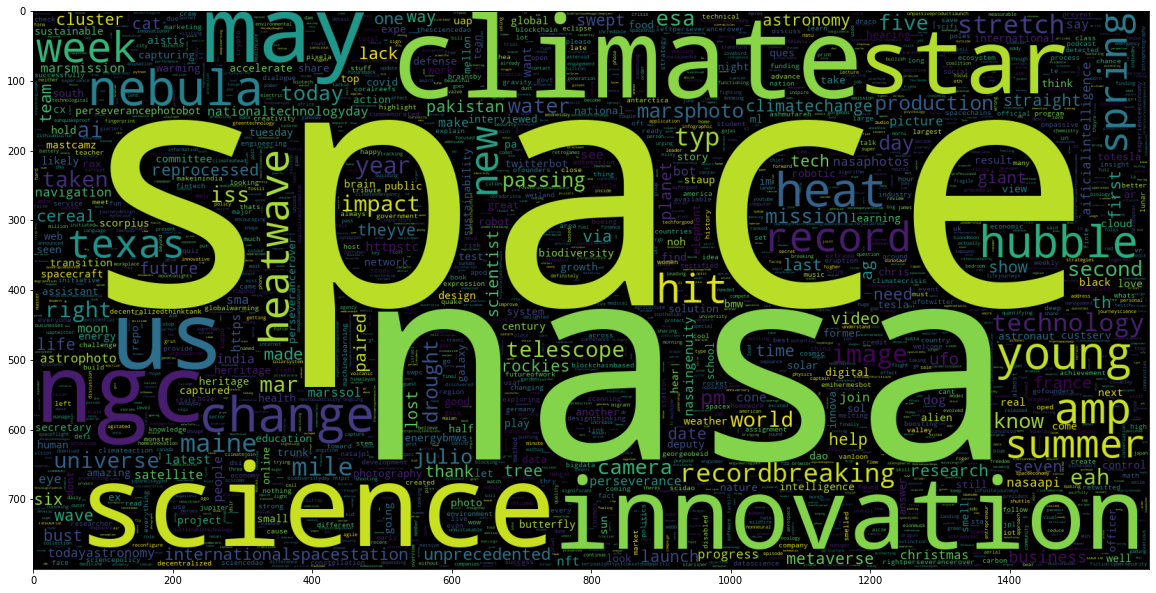

In [ ]:
# we create word cloud to visualize the bag of words cluster after stemming based on overall vectorization
from wordcloud import WordCloud
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 5000, width = 1600, height =800,collocations = False).generate(" ".join(tcs['text']))
plt.imshow(wc)

In [ ]:
# vectorization for stemmed data set :  Xst_train
Tfidf = TfidfVectorizer()
Xst_trainvector = Tfidf.fit_transform(Xst_train)
Tfidf.get_feature_names_out()
Xst_trainvector.toarray() # as we can see the vector after Tfidf fit and transformation is a sparse vector
Xst_trainVec = pd.DataFrame(Xst_trainvector.toarray(), columns = Tfidf.get_feature_names_out())
Xst_trainVec.head(3)
len(Xst_trainvector.toarray())
Xst_trainvector.shape
Xst_trainVec


,ab,abbeon,abc,abcnew,abduct,abil,abl,aboard,aboion,absolut,...,yxm,zeal,zealand,zero,zeroemissionclim,zhurong,zia,zoom,zubrin,zyne
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.24895,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
3496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
3497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
3498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0


In [ ]:
# vectorization for stemmed data set :  Xst_test
Tfidf = TfidfVectorizer()
Xst_testvector = Tfidf.fit_transform(Xst_test)
Tfidf.get_feature_names_out()
Xst_testvector.toarray() # as we can see the vector after Tfidf fit and transformation is a sparse vector
Xst_testVec = pd.DataFrame(Xst_testvector.toarray(), columns = Tfidf.get_feature_names_out())
Xst_testVec.head
Xst_testvector.shape


(1500, 4806)

3.(b) For lemmatized data, instead of Tfidf vectorization , we carry out word embedding for the train and test split samples of lemmatized corpus of words in the text

In [ ]:
#3.(b) For lemmatized data, instead of Tfidf vectorization , we carry out word embedding for the train and test split samples of lemmatized corpus of words in the text

3(b) : We apply the word2vect algorithim to the samples of lemmatized data
Xlt_train,Xlt_test. The Word2Vector algorithim will encode the word vectors , establish similarity of words in the context based on word2vector corpus and also enable us embed these words back to the train and test samples to enable ML tasks

In [ ]:
pip install gensim  # 3.6.0 version

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import gensim         # important to import gensim first and then call specific functions
from gensim.models import Word2Vec
import multiprocessing

In [ ]:
cores = multiprocessing.cpu_count()
cores

2

In [ ]:
# initializing the word2vector algorithim to Xlt_train data
Xlt_trainWVmodel =  Word2Vec(min_count = 5, window = 5, size=300, sample = 0.001, alpha = 0.03,  min_alpha =0.0001, workers = 2)
Xlt_trainWVmodel.build_vocab(Xlt_train)
Xlt_trainWVmodel.train(Xlt_train, total_examples = Xlt_trainWVmodel.corpus_count,epochs = 10)
Xlt_Wordvector = pd.DataFrame(Xlt_trainWVmodel.wv.vectors, index= Xlt_trainWVmodel.wv.index2word)
print(Xlt_trainWVmodel)

Word2Vec(vocab=27, size=300, alpha=0.03)


In [ ]:
Xlt_trainWVmodel.init_sims(replace=True)

In [ ]:
# Initiallizing the word2vector algorithim to Xlt_test data
#Xlt_testWVmodel =  Word2Vec(Xlt_test, min_count = 5, window = 5, size=300, sample = 0.001,sg =1, alpha = 0.03,  min_alpha =0.0001, workers = 2, seed = 34)
#Xlt_testWVmodel.train(Xlt_test, total_examples = Xlt_testWVmodel.corpus_count,epochs = 10)
#Xlt_Wordvector = pd.DataFrame(Xlt_testWVmodel.wv.vectors, index= Xlt_testWVmodel.wv.index2word)
#Xlt_Wordvector


In [ ]:
type(Xst_train)
type(Xst_test)
type(Xlt_train)
type(Xlt_test)

4(a) :  We now apply KNN Classifier to the data to classify the text into specific label categories

In [ ]:
# we use Xst_train and Xst_test data for KNN classification task . At first we encode the values of the label i.e target variable into (1,0)
Y_train

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5) # initiate the knn algorithim
knn_fit = knn.fit(Xst_trainVec,Y_train)  #  we run the KNN algorithim on the Xst_train which is Tf-idf vectorized data after stemming
KNeighborsClassifier(n_neighbors =5)
Y_pred = knn.kneighbors_graph(Xst_trainVec)
Y_pred.toarray()  # the resulting array is the  training models output or prediction
len(Y_pred.toarray()), Y_pred.toarray()

(3500, array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 1.]]))

There are many challenges that I am facing while trying to execute the training and prediction of the text for classification. I have tried to code the above task entirely on my own . However, I have not been able to get a clear understanding of any solution to overcome the challenges while training and then predicting the model with the test data. The key proble is due to the imbalance in the features that arise from carrying out the Tf-idf of the X train and X test data.

Will need more guidance and a deeper study of the coding alternative functions for overcoming above challenges.

Hence submission at the current level